In [1]:
import os
import glob
import json
import yaml
import numpy as np
import torch
import argparse

import sys
from pathlib import Path
__abs_path__ = str(Path.cwd().parents[0].absolute())
__utils_path__ = f'{__abs_path__}/utils'

for __util_path__ in [__abs_path__, __utils_path__]:
    if not __util_path__ in sys.path:
        sys.path+=[__util_path__]

from eval_CBD import Options, Trainer

import trimesh
from utils import ICT_face_model, YamlArgParser
from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array
)
import igl
import pickle

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
config = f'{__abs_path__}/config/train_CBD.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.dec_type = 'disp'

## version 8
# opts.ckpt = '../ckpts_CBD/2025-09-29-14-48-17-NGBCv8' ## ------> 1 1 
# opts.ckpt = '../ckpts_CBD/2025-09-29-14-48-19-NGBCv8' ## ------> 1 1 none
# opts.ckpt = '../ckpts_CBD/2025-10-05-22-59-45-NGBCv8' ## ------> 1 0

## version 5
# opts.ckpt = '../ckpts_CBD/2025-09-26-10-16-32-NGBCv5' ## ------> 1 1 
# opts.ckpt = '../ckpts_CBD/2025-09-27-08-05-11-NGBCv5' ## ------> 1 1
# opts.ckpt = '../ckpts_CBD/2025-09-27-07-44-28-NGBCv5' ## ------> 2 1
# opts.ckpt = '../ckpts_CBD/2025-09-28-15-27-33-NGBCv5' ## ------> 2 0 
opts.ckpt = '../ckpts_CBD/2025-10-09-02-04-49-NGBCv5' ## ------> 1 1 (use_data2)
# opts.ckpt = '../ckpts_CBD/2025-09-27-12-04-29-NGBCv5' ## ------> 1 0
# opts.ckpt = '../ckpts_CBD/2025-10-09-01-42-26-NGBCv5' ## ------> 1 1 (128? -> 512)
# opts.ckpt = '../ckpts_CBD/2025-10-03-22-40-03-NGBCv5' ## ------> 1 1 relu (softpou)

opts.in_type=1
opts.out_type=1

opts.num_cage_v=512
# opts.num_cage_v=128

opts.version=5

opts.last_activation='relu'
# opts.last_activation='none'

opts.no_pou=False

opts.use_data2=True
# opts.use_data2=False
opts.use_data3=False

trainer = Trainer(opts)

shape model not used!, use_shp_recon set to False
Loading... ../ckpts_CBD/2025-10-09-02-04-49-NGBCv5/model_best.pth


# Retarget single frame

(3515, 3)
(11248, 3)


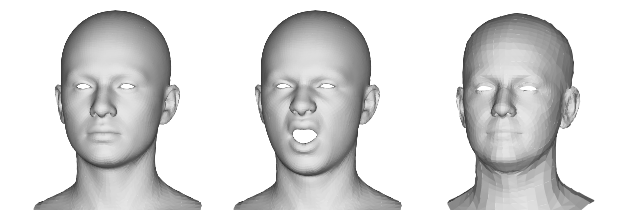

In [3]:
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

## flame
flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)
flame_tri.vertices=flame_tri.vertices+np.array([0,0.1,0])
# flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/biwi_M5.obj', process=False, maintain_order=True)
# flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/biwi_M5_deci.obj', process=False, maintain_order=True)
print(flame_tri.vertices.shape)

## ICT random expression
# bs_coeff = np.eye(53)[26]
bs_coeff = np.eye(53)[51] + np.eye(53)[52] + np.eye(53)[26] * 0.5
vertices = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))
src_mesh = ict_tri
tgt_mesh = flame_tri


print(ict_tri.vertices.shape)

M_SCALE = 0.68
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE ]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces ]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [4]:
device=trainer.device
print(device)

sd_v = ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff).squeeze(0)
# print(sd_v.shape)
s_v_B_th = torch.from_numpy(ict_tri.vertices)[None].float().to(device)
s_n_B_th = torch.from_numpy(igl.per_vertex_normals(ict_tri.vertices, ict_tri.faces))[None].float().to(device)
sd_v_B_th = torch.from_numpy(sd_v)[None].float().to(device)
sd_n_B_th = torch.from_numpy(igl.per_vertex_normals(sd_v, ict_tri.faces))[None].float().to(device)
t_v_B_th = torch.from_numpy(tgt_mesh.vertices)[None].float().to(device)
t_n_B_th = torch.from_numpy(igl.per_vertex_normals(tgt_mesh.vertices, tgt_mesh.faces))[None].float().to(device)

pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
    s_v_B_th, s_n_B_th, sd_v_B_th, sd_n_B_th, t_v_B_th, t_n_B_th, mesh_data=0, out_kw=True
)


cuda:0


 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


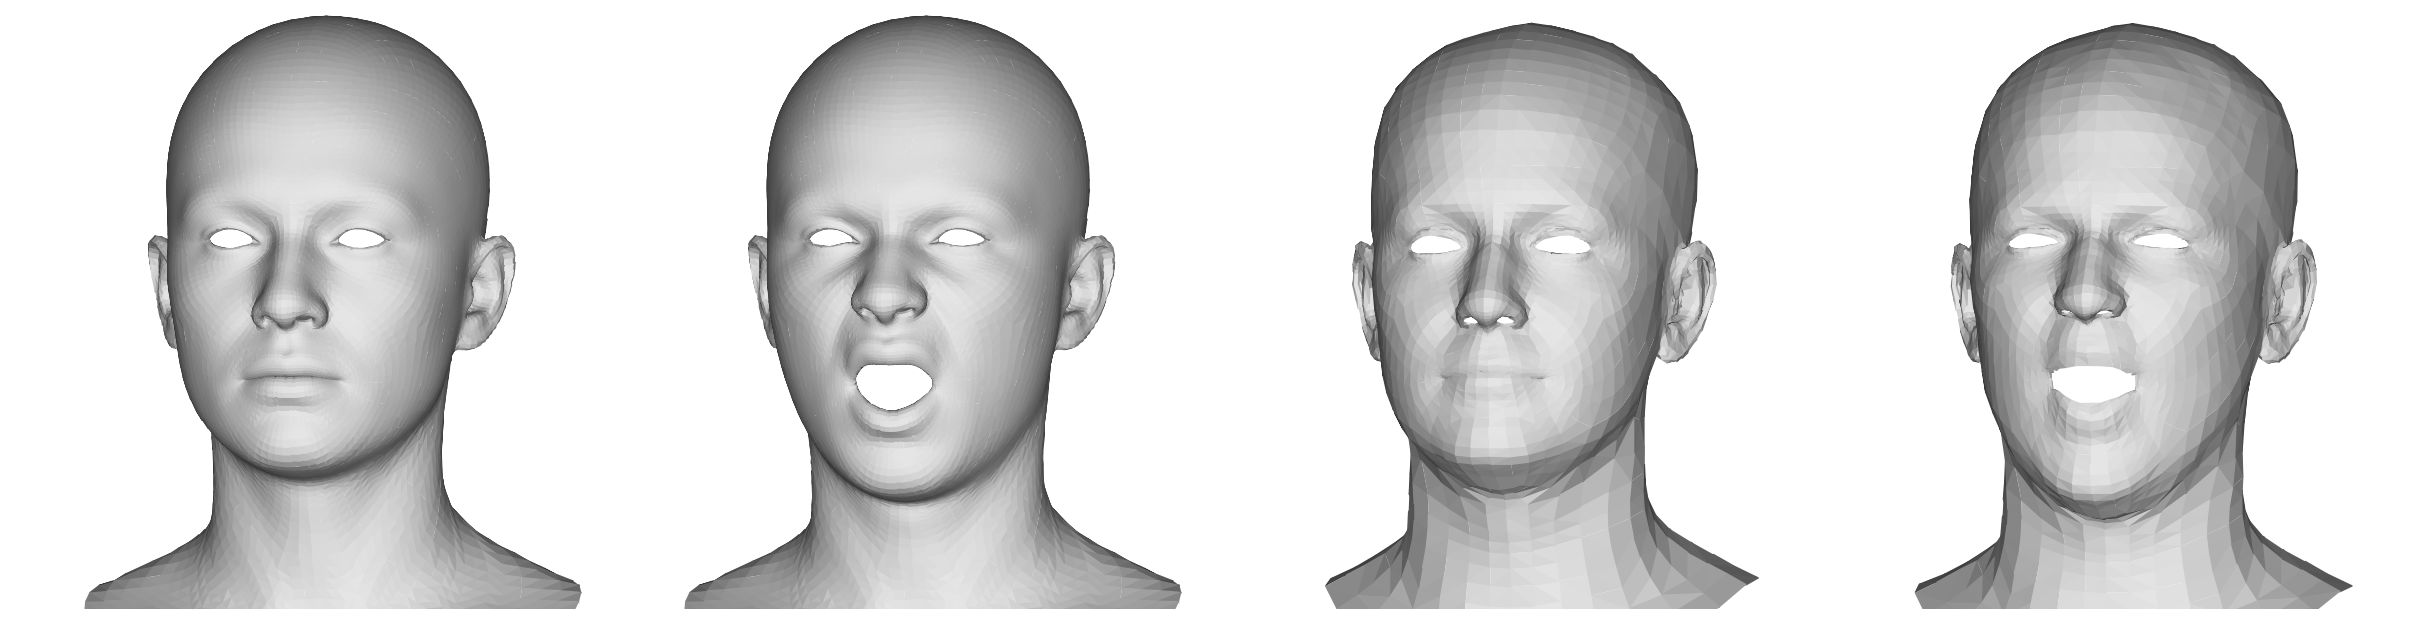

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


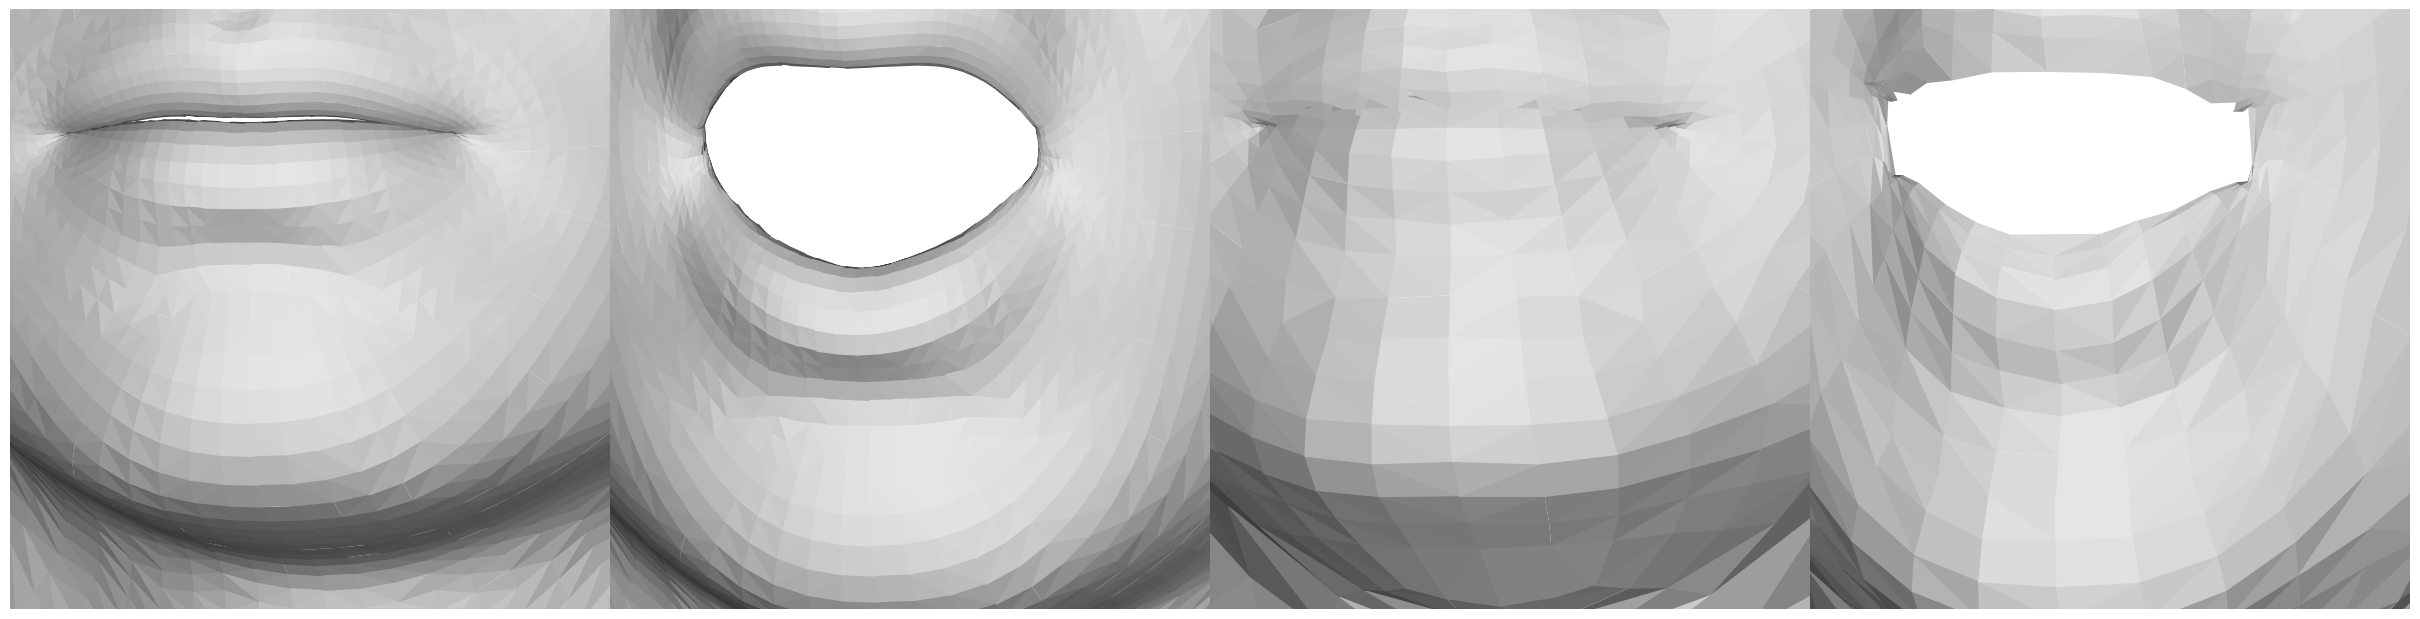

In [5]:
SIZE=6
M_SCALE=.82
SAVE=0

M_trns=np.array([0,0.,0])
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NBC-retarget", save=SAVE
)

M_SCALE=1.7
M_trns=np.array([0.1, 1.6, 0])
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NBC-retarget-zoom", save=SAVE
)

In [13]:
# SIZE=6
# M_SCALE=.82
# SAVE=0

# M_trns=np.array([0,0.,0])
# v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
# v_list = [v * M_SCALE + M_trns for v in v_list]
# f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

# print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
# plot_image_array(
#     v_list, f_list,
#     rot_list=[[0,-190,0]]*len(v_list), 
#     size=SIZE, bg_black=False, mode='shade', 
#     logdir=f"../_tmp", 
#     name=f"NBC-retarget", save=SAVE
# )

# M_SCALE=1.7
# M_trns=np.array([0.1, 1.9, 0])
# v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
# v_list = [v * M_SCALE + M_trns for v in v_list]
# f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

# print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
# plot_image_array(
#     v_list, f_list,
#     rot_list=[[0,-190,0]]*len(v_list), 
#     size=SIZE, bg_black=False, mode='shade', 
#     logdir=f"../_tmp", 
#     name=f"NBC-retarget-zoom", save=SAVE
# )

# Retarget animation

In [3]:
from dataloader_CBD import (
    EvalDataset,
    CBDDataBatch_eval,
    CBD_collate_wrapper_eval,
)
from functools import partial
from tqdm import tqdm
from glob import glob

import ipywidgets as widgets
import matplotlib.pyplot as plt

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *

In [4]:
def get_mesh(selection, dataset):
    if selection=='voca':
        mesh = dataset.voca_mesh
    elif selection=='biwi':
        mesh = dataset.biwi_mesh
    elif selection=='mf_SEN':
        mesh = dataset.mf_SEN_mesh
    elif selection=='coma':
        mesh = dataset.coma_mesh
    elif selection=='mf_ROM':
        mesh = dataset.mf_ROM_mesh
    return mesh

In [5]:
device='cuda:0'
SRC_SELECT_DATA=2
SRC_SELECT_MESH=-1

BS=16
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict'] # 0 1 2 3 4 5
src_selection = data_name_list[SRC_SELECT_DATA]


src_dataset = EvalDataset(data_name=src_selection, toggle=False) # if eve-s01
src_dataloader = torch.utils.data.DataLoader(
    src_dataset,
    batch_size=BS,
    collate_fn=partial(CBD_collate_wrapper_eval, device=device),
)
len_data = len(src_dataset)
len_dataloader = len(src_dataloader)
print(f'max data length: {len_data}')
print(f'max dataloader: {len_dataloader}')

src_mesh = get_mesh(src_selection, src_dataset)
src_mesh_list = [idname for idname in src_mesh.keys() if idname!='face']

src_v = src_mesh[src_mesh_list[SRC_SELECT_MESH]]
src_n = igl.per_vertex_normals(src_v, src_mesh['face'])

mf SEN data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_SEN_vertex_data_test.txt
max data length: 6309
max dataloader: 395


In [6]:
TGT_SELECT_DATA=4
TGT_SELECT_mesh=-1


data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict']
tgt_selection = data_name_list[TGT_SELECT_DATA]

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False) # if eve-s01

tgt_mesh = get_mesh(tgt_selection, tgt_dataset)
tgt_mesh_list = [idname for idname in tgt_mesh.keys() if idname!='face']

tgt_v = tgt_mesh[tgt_mesh_list[TGT_SELECT_mesh]]
tgt_n = igl.per_vertex_normals(tgt_v, tgt_mesh['face'])
tgt_v_th = torch.tensor(tgt_v).float()[None].to(device)
tgt_n_th = torch.tensor(tgt_n).float()[None].to(device)

mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt


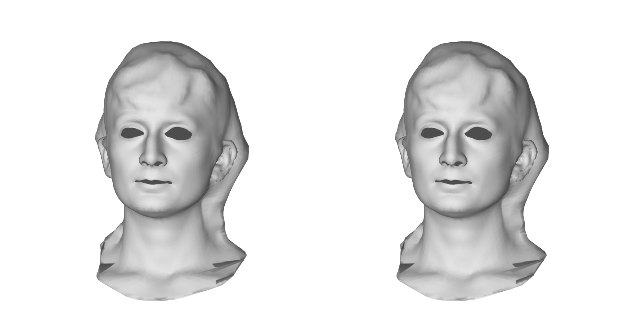

In [7]:
M_SCALE = 0.5
v_list=[ src_v, tgt_v ]
f_list=[ src_mesh['face'], tgt_mesh['face'] ]
SIZE=3
rot_list=[[0,-10,0]]
# plot_image_array(
#     v_list, f_list,
#     rot_list=[[0,-10,0]]*len(v_list), 
#     size=SIZE, bg_black=False, mode='shade', 
#     logdir=f"_tmp/train", 
#     name=f"test", save=False
# )
plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE,
        rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False)

In [8]:
# file_name = 'coma-to-mf_ROM'
# file_name = 'mf_ROM_test-to-mf_ROM_val'
# file_name = 'mf_ROM_test-to-mf_ROM_test'
file_name = 'mf_SEN_test-to-mf_SEN_test'
a2b_retarget_path = __abs_path__ + '/eval_CBD/'+opts.ckpt.split('/')[-1]+'/'+file_name
print(a2b_retarget_path)
os.makedirs(a2b_retarget_path, exist_ok=True) 

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-09-02-04-49-NGBCv5/mf_SEN_test-to-mf_SEN_test


In [9]:
FRAME = 0

# '/source/sihun/NeuralFacialAnimation/eval_CBD/2025-09-29-00-17-41-NGBCv5-eval'
pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
for index, batch in pbar:
    if FRAME == index:
        with torch.no_grad():
            pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
                batch.template, batch.template_normal, batch.vertices, batch.vertices_normal, tgt_v_th, tgt_n_th,
                mesh_data=batch.mesh_data, out_kw=True
            )

        pred_outputs_np = pred_outputs.detach().cpu().numpy()
        for b_idx in range(BS):
            np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])
        break
    else:
        continue

  0%|                                                                       | 0/395 [00:01<?, ?it/s]


     source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


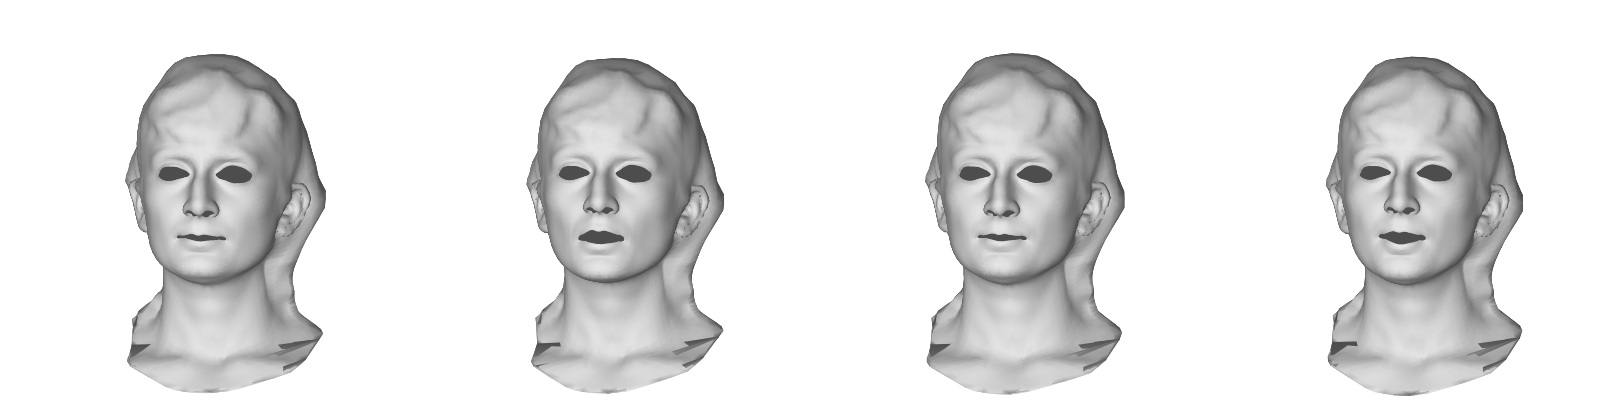

In [10]:
SIZE=6
M_SCALE=.7
SAVE=0

M_trns=np.array([0,0.,0])
v_list=[
    batch.template.detach().cpu().numpy()[0],
    batch.vertices.detach().cpu().numpy()[0],
    pred_source.detach().cpu().numpy()[0],
    pred_outputs.detach().cpu().numpy()[0],
]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ src_mesh['face'], src_mesh['face'], tgt_mesh['face'], tgt_mesh['face'] ]

print('     source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
# plot_image_array(
#     v_list, f_list,
#     rot_list=[[0,-10,0]]*len(v_list), 
#     size=SIZE, bg_black=False, mode='shade', 
#     logdir=f"../_tmp", 
#     name=f"A-to-B", save=SAVE
# )
plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE,
        rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False)

In [11]:
# '/source/sihun/NeuralFacialAnimation/eval_CBD/2025-09-29-00-17-41-NGBCv5-eval'
pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
for index, batch in pbar:
    with torch.no_grad():
        pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
            batch.template, batch.template_normal, batch.vertices, batch.vertices_normal, tgt_v_th, tgt_n_th,
            mesh_data=batch.mesh_data, out_kw=True
        )

    pred_outputs_np = pred_outputs.detach().cpu().numpy()
    for b_idx in range(BS):
        if b_idx < pred_outputs_np.shape[0]:
            np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_outputs_np[b_idx])

100%|█████████████████████████████████████████████████████████████| 395/395 [00:57<00:00,  6.87it/s]


In [94]:
# from remesh_utils import procrustes_LDM

In [13]:
# file_name = 'GT-mf_ROM_test-to-mf_ROM_test'
file_name = 'GT-mf_SEN_test-to-mf_SEN_test'

# GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/'+opts.ckpt.split('/')[-1]+'/'+file_name
GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/'+ file_name
print(GT_a2b_retarget_path)
os.makedirs(GT_a2b_retarget_path, exist_ok=True) 

pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
for index, batch in pbar:
    pred_outputs_np = batch.vertices.detach().cpu().numpy()
    for b_idx in range(BS):
        if b_idx < pred_outputs_np.shape[0]:
            np.save(GT_a2b_retarget_path+f'/{index*BS+b_idx:05d}', tmp_v)

/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_SEN_test-to-mf_SEN_test


In [14]:
print(a2b_retarget_path)
mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_mesh_file_paths=len(mesh_file_paths)
print(len(mesh_file_paths))

print(GT_a2b_retarget_path)
GT_mesh_file_paths = sorted(glob(GT_a2b_retarget_path+'/*.npy'))
GT_len_mesh_file_paths=len(GT_mesh_file_paths)
print(len(GT_mesh_file_paths))

/source/sihun/NeuralFacialAnimation/eval_CBD/2025-10-09-02-04-49-NGBCv5/mf_SEN_test-to-mf_SEN_test
6309
/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_SEN_test-to-mf_SEN_test
6309


In [93]:
src_v.shape

(5223, 3)

In [15]:
SAVE=0
rot_list=[[0,-10,0]]
M_SCALE=0.6
def update_frame(frame):
    plt.close()
    
    vvv= np.load(mesh_file_paths[frame])
    vvvGT= np.load(GT_mesh_file_paths[frame])
    
    v_list = [vvvGT, vvv]
    f_list = [tgt_mesh['face']]*len(v_list)
    plot_mesh_gouraud(
        v_list, f_list, mesh_scale=M_SCALE,
        rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False)

slider = widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1, description='Frame:')

# widgets.interactive(update_frame, frame=slider)
widgets.interact(update_frame, frame=slider)

interactive(children=(IntSlider(value=0, description='Frame:', max=6308), Output()), _dom_classes=('widget-int…

<function __main__.update_frame(frame)>

In [ ]:
import numpy as np
from utils.exp_utils import PCA_holder
import pickle
import os
from glob import glob

import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib import rc
from sklearn.decomposition import PCA
from ipywidgets import interact, FloatSlider
import matplotlib.tri as mtri

In [ ]:

# ---------- Plot Function ----------
SIZE= 5
def plot_pca_shape(**kwargs):
    # PC0 ~ PC19
    #keys = sorted(kwargs.keys(), key=lambda k: int(k[2:]))
    keys = sorted(list(kwargs.keys()))[:-1]
    visible_coeffs = np.array([kwargs[k] for k in keys])

    # 전체 100차원 중 visible 부분만 채우고 나머지는 0으로
    full_coeffs = np.zeros((1, n_components))
    full_coeffs[0, :n_slider] = visible_coeffs 
    full_coeffs = full_coeffs * np.sqrt(pca_holder.explained_variance_)
    
    model = yrotate(-kwargs["y_rot"])
    view  = translate(0, 0, -3.5)
    proj  = perspective(55, 1, 1, 100)
    MVP   = proj @ view @ model

    V_flat = pca_holder.inverse_transform(full_coeffs)
    print(V_flat.shape, V_flat.min(0), V_flat.max(0))
    
    V = V_flat.reshape(-1, 3)
    V = normalize_homogeneous(V)
    V = V @ MVP.T
    V /= V[:, 3].reshape(-1, 1)

    VF = V[faces]
    T = VF[:, :, :2]
    Z = -VF[:, :, 2].mean(axis=1)
    Z = (Z - Z.min()) / ((Z.max() - Z.min())+1e-12)
    C = plt.get_cmap("magma")(Z)
    I = np.argsort(Z)

    T, C = T[I, :], C[I, :]
    fig = plt.figure(figsize=(SIZE, SIZE))
    ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
    collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
    ax.add_collection(collection)
    plt.show()

# ===== 슬라이더 구성 (PC0~PC19) =====
sliders = {
    f"PC{i}": FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, layout={"width": "300px"})
    for i in range(n_slider)
}
sliders["y_rot"]=FloatSlider(value=0.0, min=-90, max=90, step=0.1, layout={"width": "300px"})

interact(plot_pca_shape, **sliders)

print(LST[NUM])
print('123')